In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords, movie_reviews
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Download required NLTK data (run only once)
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\dan12\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dan12\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dan12\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\dan12\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dan12\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Extraction error for punkt/PY3/polish.pickle: [Errno 28]
[nltk_data]     No space left on device


False

In [6]:
# Load NLTK movie reviews (positive / negative)
documents = [(list(movie_reviews.words(fileid)), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]

# Convert to DataFrame
data = []
for words, label in documents:
    text = " ".join(words)
    data.append({"text": text, "label": 1 if label == "pos" else 0})

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
df.head()

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Dataset shape: (2000, 2)


,text,label
0,"plot : two teen couples go to a church party ,...",0
1,the happy bastard ' s quick movie review damn ...,0
2,it is movies like these that make a jaded movi...,0
3,""" quest for camelot "" is warner bros . ' first...",0
4,synopsis : a mentally unstable man undergoing ...,0


In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_level_0(text):
    """Almost no preprocessing"""
    return text

def preprocess_level_1(text):
    """Lowercase + remove punctuation + extra spaces"""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_level_2(text):
    """Level 1 + remove stopwords"""
    text = preprocess_level_1(text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

def preprocess_level_3(text):
    """Level 2 + lemmatization"""
    text = preprocess_level_2(text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

In [9]:
levels = {
    "Level 0 (Raw)": preprocess_level_0,
    "Level 1 (Basic clean)": preprocess_level_1,
    "Level 2 (+ Stopwords)": preprocess_level_2,
    "Level 3 (+ Lemmatization)": preprocess_level_3
}

results = []

for name, func in levels.items():
    print(f"Processing: {name}")
    
    # Apply preprocessing
    cleaned = df['text'].apply(func)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        cleaned, df['label'], test_size=0.2, random_state=42, stratify=df['label']
    )
    
    # Vectorize
    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    
    # Train model
    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test_vec)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({"Preprocessing Level": name, "Accuracy": round(acc, 4)})
    print(f"Accuracy: {acc:.4f}\n")

results_df = pd.DataFrame(results)
print(results_df)

Processing: Level 0 (Raw)
Accuracy: 0.8150

Processing: Level 1 (Basic clean)
Accuracy: 0.8150

Processing: Level 2 (+ Stopwords)
Accuracy: 0.8175

Processing: Level 3 (+ Lemmatization)
Accuracy: 0.8150

         Preprocessing Level  Accuracy
0              Level 0 (Raw)    0.8150
1      Level 1 (Basic clean)    0.8150
2      Level 2 (+ Stopwords)    0.8175
3  Level 3 (+ Lemmatization)    0.8150


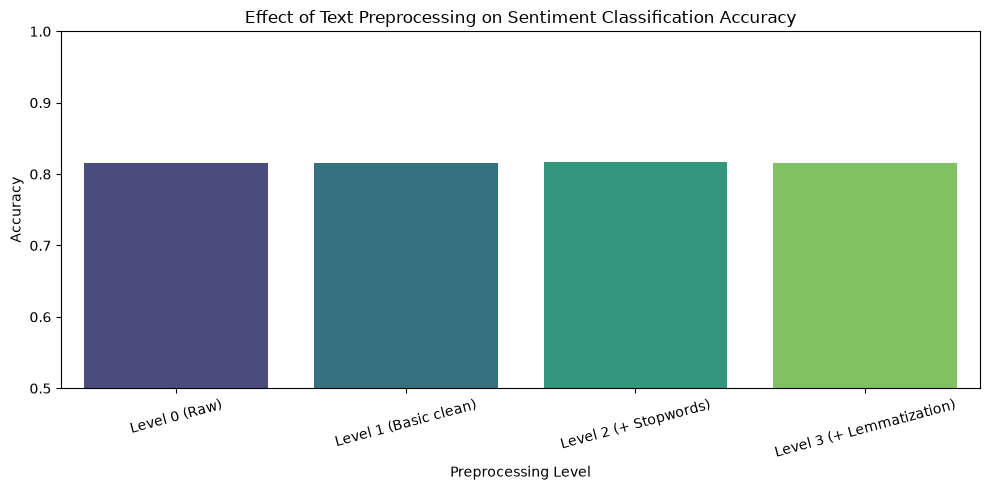

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Preprocessing Level", y="Accuracy", palette="viridis")
plt.title("Effect of Text Preprocessing on Sentiment Classification Accuracy")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../results/accuracy_comparison.png", dpi=150)
plt.show()

In [11]:
results_df.to_csv("../results/accuracy_results.csv", index=False)
print("Results saved!")

Results saved!
